(780, 1)
(780, 2)
(780, 3)
(780, 4)
(780, 5)
(780, 6)
(780, 7)
(780, 8)
(780, 9)
(780, 10)
(780, 11)
(780, 12)
(780, 13)
(780, 14)
(780, 15)
(780, 16)
(780, 17)
(780, 18)
(780, 19)
(780, 20)
(780, 21)
(780, 22)
(780, 23)
(780, 24)
(780, 25)


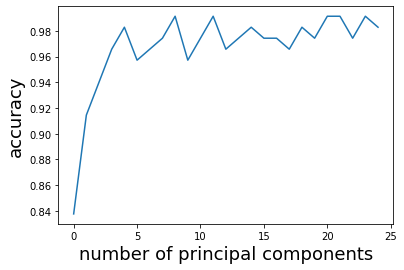

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    GaussianProcessClassifier(1.0 * RBF(1.0)),
    DecisionTreeClassifier(),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    MLPClassifier(alpha=1, max_iter=1000),
    AdaBoostClassifier(),
    GaussianNB(),
    # QuadraticDiscriminantAnalysis(),
    LogisticRegression()]

# csv1=np.genfromtxt ('/content/drive/MyDrive/all fft/PCA_M.csv', delimiter=",")
csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_M.csv', delimiter=",")
# csv2=np.genfromtxt ('/content/drive/My Drive/pca/PCA_25_lebel.csv', delimiter=",")
# csv1=np.genfromtxt ('/content/drive/MyDrive/pca/PCA_whole_25.csv', delimiter=",")#NEW
# ts = time.time() 
csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_M_label.csv', delimiter=",")
# csv2=np.genfromtxt ('/content/drive/MyDrive/all fft/FFT_M_label.csv', delimiter=",")
# target = csv2[:,:].transpose().flatten()
# print(target[0:10])

test=[]
V_test=[]
T_test=[]
for i in range(25):
#83 90 combine actually 17
  X = csv1[0:,range(i+1)] #26:78
  Y = csv2 
  # print(X.shape)

  # X = StandardScaler().fit_transform(X)
  # print(X.shape) B 85 % ss around 100% together 90 %~ 25 state 13
  #both 6, 9 a valo graph 2 components validation kortesite only beacuse of koyta components nibo ta ber korar jonno.
  #but john test korbo tokhn randomly test korbo 30 times. this time dont fixed random state
  X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25)#split traing and testing dataset randomly
  X_train, X_validation, Y_train, y_validation = train_test_split(X_train, Y_train, test_size=0.20)
  scaler = StandardScaler()
  scaler.fit(X_train)

  X_train = scaler.transform(X_train)
  X_validation = scaler.transform(X_validation)
  X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)
  clf.fit(X_train, Y_train)
  # score = clf.score(X_test, Y_test)
  
  predict_y_test = clf.predict(X_test)#[wx+b ai euationa x1,x2... bosabo .then value positive asle 1 and negative asle 0 consider]
  predict_y_train = clf.predict(X_train)
  predict_y_validation = clf.predict(X_validation)

  V_test.append(accuracy_score(y_validation,predict_y_validation))
  test.append(accuracy_score(Y_test,predict_y_test))
  T_test.append(accuracy_score(Y_train,predict_y_train))
  error = []

# Calculating error for K values between 1 and 40
  for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, Y_train)
    pred_i = knn.predict(X_validation)
    error.append(np.mean(pred_i != y_validation))
  
  # print("Test accuracy:",accuracy_score(Y_test,predict_y_test))
  # print("Training accuracy: ", accuracy_score(Y_train,predict_y_train))

# print(max(test))
# plt.plot(test)
# print(max(V_test))
plt.plot(V_test)
# plt.plot(T_test)
# plt.legend("tvT")
# plt.title("")
plt.xlabel("number of principal components",fontsize=18)
plt.ylabel("accuracy",fontsize=18)
plt.savefig("KNN.pdf")

plt.show()


#2D nd array (1950,2) vt and vw 4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
# X=csv3[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29]],20,21,22,23,24
# ,15,16,17,18,19,20,21,22,23,24 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24



# for name, clf in zip(names, classifiers):
        
#         clf.fit(X_train, Y_train)
#         score = clf.score(X_test, Y_test)
#         predict_y_test = clf.predict(X_test)#[wx+b ai euationa x1,x2... bosabo .then value positive asle 1 and negative asle 0 consider]
#         predict_y_train = clf.predict(X_train)


#         print("Test accuracy: ",name,accuracy_score(Y_test,predict_y_test))
#         print("Training accuracy: ", accuracy_score(Y_train,predict_y_train))
    # 92.85 together test=.17    ss=  test=.22


30 times validation loss measurement on mixed dataset

In [ ]:


res = []

 
for i in range(25):
  test=[]
  V_test=[]
  T_test=[]
  for iter in range(30):
  #83 90 combine actually 17
    X = csv1[:,range(i+1)] #26:78
    Y = csv2 
    # Y=target
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25, random_state = iter)#split traing and testing dataset randomly
    X_train, X_validation, Y_train, y_validation = train_test_split(X_train, Y_train, test_size=0.20, random_state = iter)
  
    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train = scaler.transform(X_train)
    X_validation = scaler.transform(X_validation)
    X_test=scaler.transform(X_test)

    # print(X_test.shape)
    clf=KNeighborsClassifier(3)
    clf.fit(X_train, Y_train)
    # score = clf.score(X_test, Y_test)
    
    predict_y_test = clf.predict(X_test)#[wx+b ai euationa x1,x2... bosabo .then value positive asle 1 and negative asle 0 consider]
    predict_y_train = clf.predict(X_train)
    predict_y_validation = clf.predict(X_validation)

    V_test.append(accuracy_score(y_validation,predict_y_validation))
    test.append(accuracy_score(Y_test,predict_y_test))
    T_test.append(accuracy_score(Y_train,predict_y_train))
  res.append(V_test)


(25, 30)


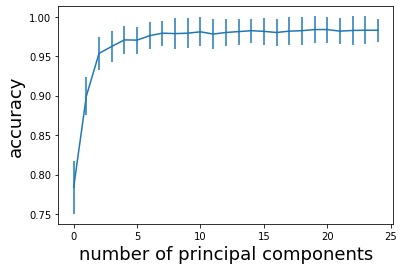

In [ ]:
import pandas as pd
df = pd.DataFrame(res)
print(df.shape)
# 
# print(df.head())
# df.T.describe()
# df.T.mean().plot()
y = list(df.T.mean())
y_std = list(df.T.std())
plt.errorbar(range(len(y)), y, yerr= y_std)
plt.xlabel("number of principal components",fontsize=18)
plt.ylabel("accuracy",fontsize=18)

plt.show()

mixed dataset accuracy

In [ ]:
import time


csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_M.csv', delimiter=",")

csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_M_label.csv', delimiter=",")

def pca():
  X = csv1[:,:6] #26:78
  # print(X.shape)
  # print(X.shape)
  

  Y = csv2 

  X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25)#split traing and testing dataset randomly
  X_train, X_validation, Y_train, y_validation = train_test_split(X_train, Y_train, test_size=0.20)
  
  # print(Y_test.shape)
  scaler = StandardScaler()
  scaler.fit(X_train)
  t0=time.time()
  X_train = scaler.transform(X_train)
  X_validation = scaler.transform(X_validation)
  X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)
  clf.fit(X_train, Y_train)
  # score = clf.score(X_test, Y_test)
  # print(score)
  t1=round(time.time()-t0, 3)
  # print ("training time:", t1, "s")

  t2=time.time()
  predict_y_test = clf.predict(X_test)
  t3=round(time.time()-t2, 3)
  # print ("testing time:", t3, "s")
  predict_y_train = clf.predict(X_train)
  predict_y_validation = clf.predict(X_validation)
  test_A=accuracy_score(Y_test,predict_y_test)
  train_A=accuracy_score(Y_train,predict_y_train)
  valid_A=accuracy_score(y_validation,predict_y_validation)
  
  return test_A,train_A,valid_A,t1,t3

 

pca()

(0.9692307692307692, 0.9764957264957265, 0.9743589743589743, 0.001, 0.007)

K-fold crosvalidation for mixed dataset

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import std

valid=[]
train=[]
test=[]
# test_acc,train_acc,val_acc,train_t,test_t=pca()
def pca():
  X = csv1[:,:6] #26:78

  Y = csv2 

  # prepare the cross-validation procedure
  cv = KFold(n_splits=10, random_state=1, shuffle=True)
  
  
  # print(Y_test.shape)
  scaler = StandardScaler()
  scaler.fit(X)
  t0=time.time()
  X = scaler.transform(X)
  # X_validation = scaler.transform(X_validation)
  # X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)

  # evaluate model
  scores = cross_val_score(clf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
  # report performance
  print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

 
pca()

Accuracy: 0.962 (0.020)


In [ ]:
import numpy 
import matplotlib.pyplot as plt
import time
# time=[]
valid=[]
train=[]
test=[]
Test_time=[]
Train_time=[]
for i in range(100):
  
  test_acc,train_acc,val_acc,train_t,test_t=pca()
  test.append(test_acc)
  train.append(train_acc)
  valid.append(val_acc)
  Train_time.append(train_t)
  Test_time.append(test_t)

# print(train)
import numpy
print(numpy.mean(train))
print(numpy.mean(valid))
# print(numpy.mean(train[-1]))
# print(numpy.mean(valid[-1]))
print(numpy.mean(test))
print(numpy.std(test)) 

0.9835042735042733
0.9643589743589744
0.9646153846153845
0.011615129900416531


for bronze

In [ ]:
import time

csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_B.csv', delimiter=",")

csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_B_label.csv', delimiter=",")
def pca():
  X = csv1[:,:6] #26:78
  # print(X.shape)

  Y = csv2 
  X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25)#split traing and testing dataset randomly
  X_train, X_validation, Y_train, y_validation = train_test_split(X_train, Y_train, test_size=0.20)
  
  # print(Y_test.shape)
  scaler = StandardScaler()
  scaler.fit(X_train)
  t0=time.time()
  X_train = scaler.transform(X_train)
  X_validation = scaler.transform(X_validation)
  X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)
  clf.fit(X_train, Y_train)
  # score = clf.score(X_test, Y_test)
  # print(score)
  t1=round(time.time()-t0, 3)
  # print ("training time:", t1, "s")

  t2=time.time()
  predict_y_test = clf.predict(X_test)
  t3=round(time.time()-t2, 3)
  # print ("testing time:", t3, "s")
  predict_y_train = clf.predict(X_train)
  predict_y_validation = clf.predict(X_validation)
  test_A=accuracy_score(Y_test,predict_y_test)
  train_A=accuracy_score(Y_train,predict_y_train)
  valid_A=accuracy_score(y_validation,predict_y_validation)
  
  return test_A,train_A,valid_A,t1,t3

 



pca()

(0.9230769230769231, 0.9743589743589743, 0.8461538461538461, 0.001, 0.003)

In [ ]:
import numpy 
import matplotlib.pyplot as plt
import time
# time=[]
valid=[]
train=[]
test=[]
Test_time=[]
Train_time=[]
for i in range(100):
  
  test_acc,train_acc,val_acc,train_t,test_t=pca()
  test.append(test_acc)
  train.append(train_acc)
  valid.append(val_acc)
  Train_time.append(train_t)
  Test_time.append(test_t)

# print(train)
import numpy
print(numpy.mean(train))
print(numpy.mean(valid))
# print(numpy.mean(train[-1]))
# print(numpy.mean(valid[-1]))
print(numpy.mean(test))
print(numpy.std(test)) 

0.9612179487179487
0.9061538461538461
0.9009230769230769
0.03636240987711082


k fold cros validation for bronze

In [ ]:
csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_B.csv', delimiter=",")

csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_B_label.csv', delimiter=",")

def pca():
  X = csv1[:,:6] #26:78

  Y = csv2 

  # prepare the cross-validation procedure
  cv = KFold(n_splits=10, random_state=1, shuffle=True)
  
  
  # print(Y_test.shape)
  scaler = StandardScaler()
  scaler.fit(X)
  t0=time.time()
  X = scaler.transform(X)
  # X_validation = scaler.transform(X_validation)
  # X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)

  # evaluate model
  scores = cross_val_score(clf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
  # report performance
  print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

pca()

Accuracy: 0.908 (0.058)


Foe stainless steel

In [ ]:
import time

csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_SS.csv', delimiter=",")

# ts = time.time() 
csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_SS_label.csv', delimiter=",")
def pca():
  X = csv1[:,:6] #26:78
  # print(X.shape)
  Y = csv2

  X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25)#split traing and testing dataset randomly
  X_train, X_validation, Y_train, y_validation = train_test_split(X_train, Y_train, test_size=0.20)
  # print(X_train.shape)
  scaler = StandardScaler()
  scaler.fit(X_train)
  t0=time.time()
  X_train = scaler.transform(X_train)
  X_validation = scaler.transform(X_validation)
  X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)
  clf.fit(X_train, Y_train)
  t1=time.time()-t0
  # score = clf.score(X_test, Y_test)
  # print(score)
  t2=time.time()
  
  
  predict_y_test = clf.predict(X_test)
  t3=time.time()-t2
  predict_y_train = clf.predict(X_train)
  predict_y_validation = clf.predict(X_validation)
  test_A=accuracy_score(Y_test,predict_y_test)
  train_A=accuracy_score(Y_train,predict_y_train)
  valid_A=accuracy_score(y_validation,predict_y_validation)

  return test_A,train_A,valid_A,t1,t3
 
pca()
Test_time=[]
Train_time=[]
valid_SS=[]
train_SS=[]
test_SS=[]
for i in range(25):
  test_acc,train_acc,val_acc,train_t,test_t=pca()
  test_SS.append(test_acc)
  train_SS.append(train_acc)
  valid_SS.append(val_acc)
  Train_time.append(train_t)
  Test_time.append(test_t)

# print(train)
import numpy
# print(numpy.mean(Train_time))
# print(numpy.mean(Test_time))
print(numpy.mean(train_SS))
print(numpy.mean(valid_SS))
print(numpy.mean(test_SS))
print(numpy.std(test_SS)) 
  
 


0.9923076923076924
0.9892307692307694
0.9923076923076922
0.007844645405527356


k fold cross-validation for SS

In [ ]:
csv1=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/PCA_SS.csv', delimiter=",")

# ts = time.time() 
csv2=np.genfromtxt ('/content/drive/MyDrive/Colab Notebooks/PCA+KNN/FFT_SS_label.csv', delimiter=",")

def pca():
  X = csv1[:,:6] #26:78

  Y = csv2 

  # prepare the cross-validation procedure
  cv = KFold(n_splits=10, random_state=1, shuffle=True)
  
  
  # print(Y_test.shape)
  scaler = StandardScaler()
  scaler.fit(X)
  t0=time.time()
  X = scaler.transform(X)
  # X_validation = scaler.transform(X_validation)
  # X_test=scaler.transform(X_test)

  # print(X_test.shape)
  clf=KNeighborsClassifier(3)

  # evaluate model
  scores = cross_val_score(clf, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
  # report performance
  print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

pca()  

Accuracy: 0.992 (0.009)


In [ ]:
other = pd.DataFrame({'key': ['K1', 'K0', 'K2'],
                      'B': ['B0', 'B1', 'B2']})